#### Cyclic ID Analysis: E. coli network 

This notebook runs a causal identiability analysis on an E. coli gene regulatory network using the cyclic ID algorithm.

There are 2 phases:

1. **Baseline testing:** Single gene perturbation queries; for each pair of genes in which we test the gene that is downstream.

2. **Additional perturbation testing:** For each unidentifiable query from the first phase of testing, we add a second perturbation from the same gene list as a second perturbation and ask whether it turns an unidentifiable query to identifiable. 



In [ ]:
# import necessary libraries

import csv
import json
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from y0.algorithm.identify.cyclic_id import cyclic_id
from y0.algorithm.identify.utils import Unidentifiable
from y0.algorithm.ioscm.utils import get_apt_order
from y0.dsl import P, Variable
from y0.graph import NxMixedGraph

#### Data Loading

There are two two data sources being used:

1. **E. coli Gene Regulatory Network** — a full directed graph of 2,976 nodes and 9,211 edges 
representing gene regulatory interactions.

2. **Single Gene Perturbations** — a list of unique genes that have been perturbed already.


In [24]:
## loading the data in

ecoli_graph = nx.read_graphml("ecoli_full_network_no_small_rna.graphml")

# load the perturbation data
csv_genes = set()
with open("supptable1.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        name = row["Perturbation Name"]

        if "off" not in name.lower() and "AAV" not in name:
            csv_genes.add(name)


# filter to genes present in the network we have
network_nodes = set(ecoli_graph.nodes())
valid_genes = csv_genes & network_nodes
excluded_genes = csv_genes - network_nodes

print(f"Total unique genes in CSV: {len(csv_genes)}")
print(f"Total valid genes in network: {len(valid_genes)}")
print(f"Total excluded genes not in network: {len(excluded_genes)}")

# print the top 5 unique genes in the CSV
print("Top 5 unique genes in CSV:")
for i, gene in enumerate(list(valid_genes)[:5]):
    print(f"{i + 1}. {gene}")

Total unique genes in CSV: 60
Total valid genes in network: 50
Total excluded genes not in network: 10
Top 5 unique genes in CSV:
1. aroF
2. lacI
3. ycjW
4. lacZ
5. fadR


#### Building the Testing and Queries

For the baseline analysis, we construct query pairs where the gene being intervened on is directly downstream of the other. Both the intervention and outcome gene must be present in the perturbation gene list. Self-loops are excluded from this. 

In [25]:
# Single gene perturbations as a baseline test

query_pairs = []

for gene in valid_genes:
    downstream = list(ecoli_graph.successors(gene))
    for target in downstream:
        # both intervention and outcome must be in valid_genes
        # exclude self-loops
        if target in valid_genes and target != gene:
            query_pairs.append((gene, target))

print(f"Total unique query pairs: {len(query_pairs)}")
print("\nAll pairs:")
for intervention, outcome in query_pairs:
    print(f"  do({intervention}) -> {outcome}")

Total unique query pairs: 67

All pairs:
  do(lacI) -> lacZ
  do(fadR) -> iclR
  do(torR) -> gadE
  do(torR) -> rpoS
  do(cra) -> crp
  do(cra) -> marA
  do(cra) -> marR
  do(cra) -> pdhR
  do(cra) -> poxB
  do(arcA) -> argR
  do(arcA) -> fnr
  do(arcA) -> gadE
  do(arcA) -> rpoS
  do(rpoH) -> cra
  do(rpoH) -> tyrR
  do(rpoH) -> yjhI
  do(phoB) -> argP
  do(phoB) -> cra
  do(phoB) -> phnF
  do(rpoS) -> cpxR
  do(rpoS) -> gadE
  do(rpoS) -> pdhR
  do(rpoS) -> poxB
  do(rpoS) -> rpoH
  do(rpoS) -> yciT
  do(crp) -> gadE
  do(crp) -> glnG
  do(crp) -> glpR
  do(crp) -> lacI
  do(crp) -> lacZ
  do(crp) -> lgoR
  do(crp) -> marA
  do(crp) -> marR
  do(crp) -> pdhR
  do(crp) -> plaR
  do(crp) -> rpoH
  do(crp) -> rpoS
  do(crp) -> sgcR
  do(crp) -> uxuR
  do(crp) -> yjhI
  do(marR) -> marA
  do(argR) -> aroK
  do(argR) -> lrp
  do(glaR) -> bdcR
  do(glaR) -> pdhR
  do(uxuR) -> lgoR
  do(gadE) -> lrp
  do(tyrR) -> aroF
  do(tyrR) -> aroL
  do(hns) -> gadE
  do(hns) -> lacZ
  do(hns) -> lrp
 

#### Explanation of Results

identified **67 unique query pairs** from the 50 perturbation genes.

Notable patterns:
- **crp** has the most downstream targets (14 pairs), 
- **rpoS** and **arcA** are also highly connected, each regulating multiple targets in 
the list


In [16]:
# baseline identifiability check using cyclic_id for each query


# convert networkx graph to NxMixedGraph for cyclic_id
directed_edges = list(ecoli_graph.edges())
ecoli_mixed = NxMixedGraph.from_edges(directed=directed_edges)

# precompute apt-order once for the full graph
print("Computing apt-order...")
apt_order = get_apt_order(ecoli_mixed)
print("Done!\n")

identifiable = []
unidentifiable = []

for i, (intervention, outcome) in enumerate(query_pairs):
    print(f"Progress: {i + 1}/{len(query_pairs)} — do({intervention}) -> {outcome}", end=" ")
    try:
        result = cyclic_id(
            graph=ecoli_mixed,
            outcomes={Variable(outcome)},
            interventions={Variable(intervention)},
            ordering=apt_order,
        )
        identifiable.append((intervention, outcome, result))
        print("✓ Identifiable")
    except Unidentifiable:
        unidentifiable.append((intervention, outcome))
        print("✗ Unidentifiable")

print("\n--- Phase 1 Results ---")
print(f"Total unique queries: {len(query_pairs)}")
print(f"Identifiable:   {len(identifiable)} ({len(identifiable) / len(query_pairs) * 100:.1f}%)")
print(
    f"Unidentifiable: {len(unidentifiable)} ({len(unidentifiable) / len(query_pairs) * 100:.1f}%)"
)

Computing apt-order...
Done!

Progress: 1/67 — do(lacI) -> lacZ ✓ Identifiable
Progress: 2/67 — do(fadR) -> iclR ✓ Identifiable
Progress: 3/67 — do(torR) -> gadE ✗ Unidentifiable
Progress: 4/67 — do(torR) -> rpoS ✗ Unidentifiable
Progress: 5/67 — do(cra) -> crp ✗ Unidentifiable
Progress: 6/67 — do(cra) -> marA ✗ Unidentifiable
Progress: 7/67 — do(cra) -> marR ✗ Unidentifiable
Progress: 8/67 — do(cra) -> pdhR ✗ Unidentifiable
Progress: 9/67 — do(cra) -> poxB ✗ Unidentifiable
Progress: 10/67 — do(arcA) -> argR ✗ Unidentifiable
Progress: 11/67 — do(arcA) -> fnr ✗ Unidentifiable
Progress: 12/67 — do(arcA) -> gadE ✗ Unidentifiable
Progress: 13/67 — do(arcA) -> rpoS ✗ Unidentifiable
Progress: 14/67 — do(rpoH) -> cra ✗ Unidentifiable
Progress: 15/67 — do(rpoH) -> tyrR ✗ Unidentifiable
Progress: 16/67 — do(rpoH) -> yjhI ✗ Unidentifiable
Progress: 17/67 — do(phoB) -> argP ✗ Unidentifiable
Progress: 18/67 — do(phoB) -> cra ✗ Unidentifiable
Progress: 19/67 — do(phoB) -> phnF ✗ Unidentifiable
Prog

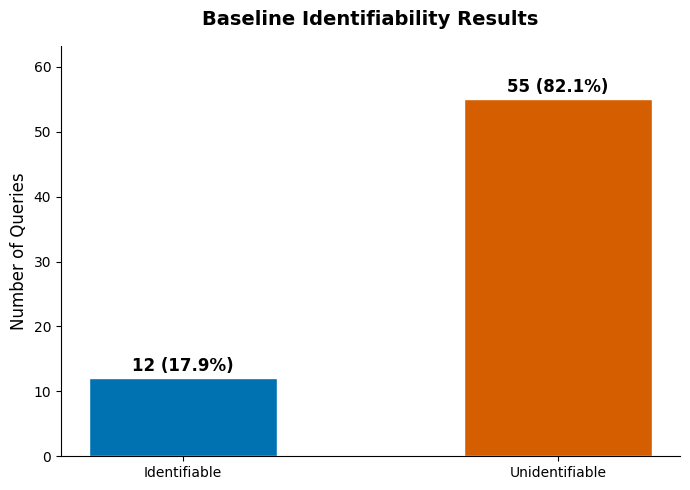

In [ ]:
# setting colors for the bar chart
colors = ["#0072B2", "#D55E00"]  # blue for identifiable, orange-red for unidentifiable

labels = ["Identifiable", "Unidentifiable"]
values = [len(identifiable), len(unidentifiable)]
percentages = [
    len(identifiable) / len(query_pairs) * 100,
    len(unidentifiable) / len(query_pairs) * 100,
]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor="white")


for bar, value, pct in zip(bars, values, percentages, strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

# setting the title and labels
ax.set_title("Baseline Identifiability Results", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Queries", fontsize=12)
ax.set_ylim(0, max(values) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
# full network scope for base distribution (required for correct marginalization)
all_network_vars = {Variable(g) for g in ecoli_graph.nodes()}

# load checkpoint if it exists
checkpoint_path = "phase2_checkpoint.json"
if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        checkpoint = json.load(f)
    phase2_results = checkpoint["results"]
    completed = set(tuple(x) for x in checkpoint["completed"])
    print(
        f"Resuming from checkpoint: {len(phase2_results)} results, {len(completed)} queries completed"
    )
else:
    phase2_results = []
    completed = set()
    print("Starting fresh Phase 2 run")

for idx, (tf1, outcome) in enumerate(unidentifiable):
    print(f"\nQuery {idx + 1}/{len(unidentifiable)}: do({tf1}) -> {outcome}")

    for tf2 in valid_genes:
        if tf2 == tf1:
            continue
        if tf2 == outcome:
            continue

        # skip if already completed
        if (tf1, tf2, outcome) in completed:
            continue

        try:
            result = cyclic_id(
                graph=ecoli_mixed,
                outcomes={Variable(outcome)},
                interventions={Variable(tf1)},
                ordering=apt_order,
                base_distribution=P[{Variable(tf2)}](all_network_vars),
            )
            phase2_results.append((tf1, tf2, outcome, True, str(result)))
            print(f"  + do({tf2}) as background -> ✓ Identifiable")

        except Unidentifiable:
            phase2_results.append((tf1, tf2, outcome, False, None))

        completed.add((tf1, tf2, outcome))

        # checkpoint every 50 queries
        if len(completed) % 50 == 0:
            with open(checkpoint_path, "w") as f:
                json.dump({"results": phase2_results, "completed": list(completed)}, f)
            print(f"  [Checkpoint saved: {len(completed)} queries done]")

# final save
with open(checkpoint_path, "w") as f:
    json.dump({"results": phase2_results, "completed": list(completed)}, f)

# summary
resolved = set((tf1, outcome) for tf1, tf2, outcome, found, _ in phase2_results if found)
still_unidentifiable = set((tf1, outcome) for tf1, outcome in unidentifiable) - resolved

print("\n--- Phase 2 Results ---")
print(f"Unidentifiable queries from Phase 1: {len(unidentifiable)}")
print(f"Resolved with second perturbation:   {len(resolved)}")
print(f"Still unidentifiable:                {len(still_unidentifiable)}")

Starting fresh Phase 2 run

Query 1/55: do(torR) -> gadE

Query 2/55: do(torR) -> rpoS
  [Checkpoint saved: 50 queries done]

Query 3/55: do(cra) -> crp
  [Checkpoint saved: 100 queries done]

Query 4/55: do(cra) -> marA
  [Checkpoint saved: 150 queries done]

Query 5/55: do(cra) -> marR
  [Checkpoint saved: 200 queries done]

Query 6/55: do(cra) -> pdhR
  [Checkpoint saved: 250 queries done]

Query 7/55: do(cra) -> poxB
  [Checkpoint saved: 300 queries done]

Query 8/55: do(arcA) -> argR
  [Checkpoint saved: 350 queries done]

Query 9/55: do(arcA) -> fnr
  [Checkpoint saved: 400 queries done]

Query 10/55: do(arcA) -> gadE
  [Checkpoint saved: 450 queries done]

Query 11/55: do(arcA) -> rpoS
  [Checkpoint saved: 500 queries done]

Query 12/55: do(rpoH) -> cra
  [Checkpoint saved: 550 queries done]

Query 13/55: do(rpoH) -> tyrR
  [Checkpoint saved: 600 queries done]

Query 14/55: do(rpoH) -> yjhI
  [Checkpoint saved: 650 queries done]

Query 15/55: do(phoB) -> argP
  + do(rpoH) as bac

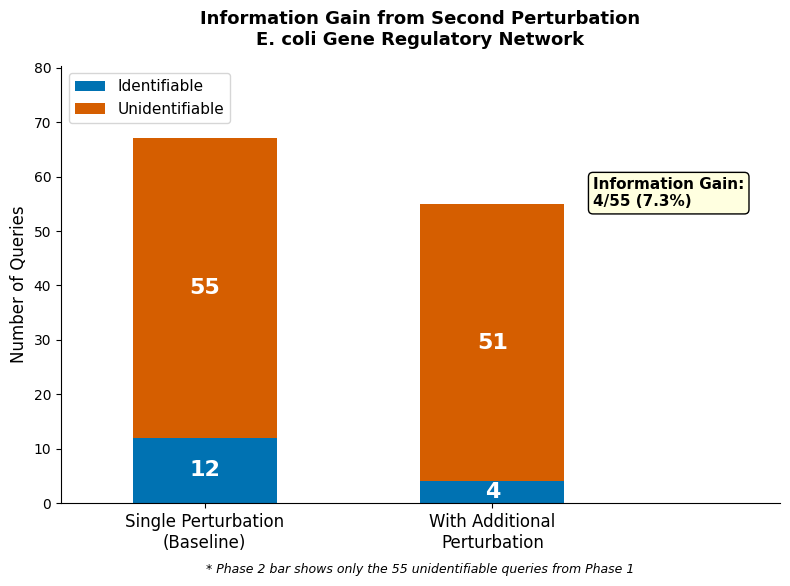

In [37]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 6))

# color-blind friendly colors (Wong palette)
color_identifiable = "#0072B2"  # blue
color_unidentifiable = "#D55E00"  # orange-red

# Phase 1 baseline bar — show identifiable (bottom) and unidentifiable (top)
ax.bar(0, len(identifiable), color=color_identifiable, width=0.5)
ax.bar(0, len(unidentifiable), bottom=len(identifiable), color=color_unidentifiable, width=0.5)
ax.text(
    0,
    len(identifiable) / 2,
    str(len(identifiable)),
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color="white",
)
ax.text(
    0,
    len(identifiable) + len(unidentifiable) / 2,
    str(len(unidentifiable)),
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color="white",
)

# Phase 2 stacked bar — resolved (blue) on bottom, still unidentifiable (red) on top
ax.bar(1, len(resolved), color=color_identifiable, width=0.5)
ax.bar(1, len(still_unidentifiable), bottom=len(resolved), color=color_unidentifiable, width=0.5)
ax.text(
    1,
    len(resolved) / 2,
    str(len(resolved)),
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color="white",
)
ax.text(
    1,
    len(resolved) + len(still_unidentifiable) / 2,
    str(len(still_unidentifiable)),
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color="white",
)

# information gain box
info_gain_pct = len(resolved) / len(unidentifiable) * 100
ax.text(
    1.35,
    len(query_pairs) * 0.85,
    f"Information Gain:\n{len(resolved)}/{len(unidentifiable)} ({info_gain_pct:.1f}%)",
    ha="left",
    va="center",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="black"),
)

# legend
legend_elements = [
    Patch(facecolor=color_identifiable, label="Identifiable"),
    Patch(facecolor=color_unidentifiable, label="Unidentifiable"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11)

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Single Perturbation\n(Baseline)", "With Additional\nPerturbation"], fontsize=12
)
ax.set_ylabel("Number of Queries", fontsize=12)
ax.set_title(
    "Information Gain from Second Perturbation\nE. coli Gene Regulatory Network",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlim(-0.5, 2)
ax.set_ylim(0, len(query_pairs) * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# clarifying note about Phase 2 bar
ax.text(
    0.5,
    -0.16,
    "* Phase 2 bar shows only the 55 unidentifiable queries from Phase 1",
    ha="center",
    transform=ax.transAxes,
    fontsize=9,
    style="italic",
    color="black",
)

plt.tight_layout()
plt.show()

In [39]:
# phase 3 testing: dual regulator pairs
# pattern:
#   TF1 -------
#                | ----> gene1
#   TF2 -------

dual_regulator_pairs = []

for outcome in set(o for _, o in query_pairs):
    # get all direct regulators of outcome that are in valid_genes
    regulators = [g for g in ecoli_graph.predecessors(outcome) if g in valid_genes and g != outcome]

    # find all pairs of co-regulators for this outcome
    for tf1 in regulators:
        for tf2 in regulators:
            if tf1 != tf2:
                dual_regulator_pairs.append((tf1, tf2, outcome))

print(f"Total dual-regulator pairs: {len(dual_regulator_pairs)}")
print("\nAll pairs:")
for tf1, tf2, outcome in dual_regulator_pairs:
    print(f"  do({tf1}) -> {outcome} with do({tf2}) as background")

Total dual-regulator pairs: 120

All pairs:
  do(marA) -> lacZ with do(crp) as background
  do(marA) -> lacZ with do(lacI) as background
  do(marA) -> lacZ with do(hns) as background
  do(crp) -> lacZ with do(marA) as background
  do(crp) -> lacZ with do(lacI) as background
  do(crp) -> lacZ with do(hns) as background
  do(lacI) -> lacZ with do(marA) as background
  do(lacI) -> lacZ with do(crp) as background
  do(lacI) -> lacZ with do(hns) as background
  do(hns) -> lacZ with do(marA) as background
  do(hns) -> lacZ with do(crp) as background
  do(hns) -> lacZ with do(lacI) as background
  do(phoB) -> cra with do(rpoH) as background
  do(rpoH) -> cra with do(phoB) as background
  do(rpoS) -> rpoH with do(cpxR) as background
  do(rpoS) -> rpoH with do(crp) as background
  do(cpxR) -> rpoH with do(rpoS) as background
  do(cpxR) -> rpoH with do(crp) as background
  do(crp) -> rpoH with do(rpoS) as background
  do(crp) -> rpoH with do(cpxR) as background
  do(crp) -> lgoR with do(uxuR) as

In [41]:
# running the 120 dual-regulator queries

# For each dual-regulator pair, run cyclic_id with TF1 as the
# intervention, gene1 as the outcome, and TF2 as background
# interventional data. This tests whether having experimental
# data from do(TF2) resolves the causal effect of do(TF1) on
# their shared downstream target gene1.

# load checkpoint if it exists
checkpoint_path_p3 = "phase3_checkpoint.json"
if os.path.exists(checkpoint_path_p3):
    with open(checkpoint_path_p3) as f:
        checkpoint = json.load(f)
    phase3_results = checkpoint["results"]
    completed_p3 = set(tuple(x) for x in checkpoint["completed"])
    print(
        f"Resuming from checkpoint: {len(phase3_results)} results, {len(completed_p3)} queries completed"
    )
else:
    phase3_results = []
    completed_p3 = set()
    print("Starting Phase 3 run...")

for idx, (tf1, tf2, outcome) in enumerate(dual_regulator_pairs):
    print(
        f"Query {idx + 1}/{len(dual_regulator_pairs)}: do({tf1}) -> {outcome} with do({tf2}) as background",
        end=" ",
    )

    if (tf1, tf2, outcome) in completed_p3:
        continue

    try:
        result = cyclic_id(
            graph=ecoli_mixed,
            outcomes={Variable(outcome)},
            interventions={Variable(tf1)},
            ordering=apt_order,
            base_distribution=P[{Variable(tf2)}](all_network_vars),
        )
        phase3_results.append((tf1, tf2, outcome, True, str(result)))
        print("✓ Identifiable")

    except Unidentifiable:
        phase3_results.append((tf1, tf2, outcome, False, None))
        print("✗ Unidentifiable")

    completed_p3.add((tf1, tf2, outcome))

    # checkpoint every 50 queries
    if len(completed_p3) % 50 == 0:
        with open(checkpoint_path_p3, "w") as f:
            json.dump({"results": phase3_results, "completed": list(completed_p3)}, f)
        print(f"  [Checkpoint saved: {len(completed_p3)} queries done]")

# final save
with open(checkpoint_path_p3, "w") as f:
    json.dump({"results": phase3_results, "completed": list(completed_p3)}, f)

# summary
p3_resolved = set((tf1, outcome) for tf1, tf2, outcome, found, _ in phase3_results if found)
p3_unidentifiable = set(
    (tf1, outcome) for tf1, tf2, outcome, found, _ in phase3_results if not found
)

print("\n--- Phase 3 Results ---")
print(f"Total dual-regulator pairs: {len(dual_regulator_pairs)}")
print(
    f"Identifiable:   {len(p3_resolved)} ({len(p3_resolved) / len(dual_regulator_pairs) * 100:.1f}%)"
)
print(
    f"Unidentifiable: {len(p3_unidentifiable)} ({len(p3_unidentifiable) / len(dual_regulator_pairs) * 100:.1f}%)"
)

Starting Phase 3 run...
Query 1/120: do(marA) -> lacZ with do(crp) as background ✓ Identifiable
Query 2/120: do(marA) -> lacZ with do(lacI) as background ✓ Identifiable
Query 3/120: do(marA) -> lacZ with do(hns) as background ✓ Identifiable
Query 4/120: do(crp) -> lacZ with do(marA) as background ✗ Unidentifiable
Query 5/120: do(crp) -> lacZ with do(lacI) as background ✗ Unidentifiable
Query 6/120: do(crp) -> lacZ with do(hns) as background ✗ Unidentifiable
Query 7/120: do(lacI) -> lacZ with do(marA) as background ✓ Identifiable
Query 8/120: do(lacI) -> lacZ with do(crp) as background ✓ Identifiable
Query 9/120: do(lacI) -> lacZ with do(hns) as background ✓ Identifiable
Query 10/120: do(hns) -> lacZ with do(marA) as background ✗ Unidentifiable
Query 11/120: do(hns) -> lacZ with do(crp) as background ✗ Unidentifiable
Query 12/120: do(hns) -> lacZ with do(lacI) as background ✗ Unidentifiable
Query 13/120: do(phoB) -> cra with do(rpoH) as background ✗ Unidentifiable
Query 14/120: do(rpoH)

In [42]:
p3_identifiable = [(tf1, tf2, outcome) for tf1, tf2, outcome, found, _ in phase3_results if found]
p3_unidentifiable = [
    (tf1, tf2, outcome) for tf1, tf2, outcome, found, _ in phase3_results if not found
]

print("\n--- Phase 3 Results ---")
print(f"Total dual-regulator pairs: {len(dual_regulator_pairs)}")
print(
    f"Identifiable:   {len(p3_identifiable)} ({len(p3_identifiable) / len(dual_regulator_pairs) * 100:.1f}%)"
)
print(
    f"Unidentifiable: {len(p3_unidentifiable)} ({len(p3_unidentifiable) / len(dual_regulator_pairs) * 100:.1f}%)"
)


--- Phase 3 Results ---
Total dual-regulator pairs: 120
Identifiable:   17 (14.2%)
Unidentifiable: 103 (85.8%)


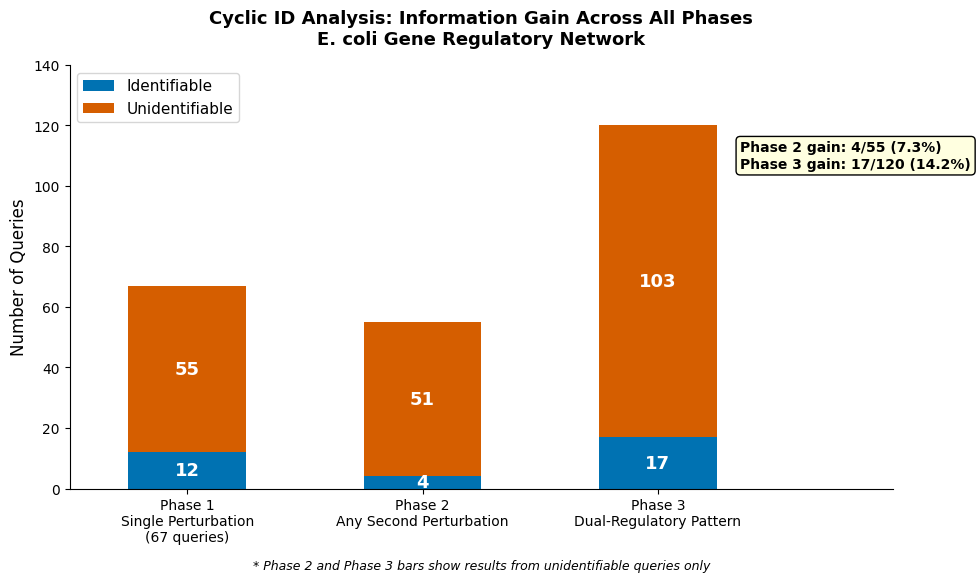

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

color_identifiable = "#0072B2"  # blue
color_unidentifiable = "#D55E00"  # orange-red

# --- Phase 1 bar ---
ax.bar(0, len(identifiable), color=color_identifiable, width=0.5)
ax.bar(0, len(unidentifiable), bottom=len(identifiable), color=color_unidentifiable, width=0.5)
ax.text(
    0,
    len(identifiable) / 2,
    str(len(identifiable)),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white",
)
ax.text(
    0,
    len(identifiable) + len(unidentifiable) / 2,
    str(len(unidentifiable)),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white",
)

# --- Phase 2 bar ---
ax.bar(1, len(resolved), color=color_identifiable, width=0.5)
ax.bar(1, len(still_unidentifiable), bottom=len(resolved), color=color_unidentifiable, width=0.5)
ax.text(
    1,
    len(resolved) / 2,
    str(len(resolved)),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white",
)
ax.text(
    1,
    len(resolved) + len(still_unidentifiable) / 2,
    str(len(still_unidentifiable)),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white",
)

# --- Phase 3 bar ---
ax.bar(2, len(p3_identifiable), color=color_identifiable, width=0.5)
ax.bar(
    2, len(p3_unidentifiable), bottom=len(p3_identifiable), color=color_unidentifiable, width=0.5
)
ax.text(
    2,
    len(p3_identifiable) / 2,
    str(len(p3_identifiable)),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white",
)
ax.text(
    2,
    len(p3_identifiable) + len(p3_unidentifiable) / 2,
    str(len(p3_unidentifiable)),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="white",
)

# information gain box
ax.text(
    2.35,
    110,
    f"Phase 2 gain: {len(resolved)}/{len(unidentifiable)} ({len(resolved) / len(unidentifiable) * 100:.1f}%)\n"
    f"Phase 3 gain: {len(p3_identifiable)}/{len(dual_regulator_pairs)} ({len(p3_identifiable) / len(dual_regulator_pairs) * 100:.1f}%)",
    ha="left",
    va="center",
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="black"),
)

# legend
legend_elements = [
    Patch(facecolor=color_identifiable, label="Identifiable"),
    Patch(facecolor=color_unidentifiable, label="Unidentifiable"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=11)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(
    [
        "Phase 1\nSingle Perturbation\n(67 queries)",
        "Phase 2\nAny Second Perturbation\n",
        "Phase 3\nDual-Regulatory Pattern\n",
    ],
    fontsize=10,
)
ax.set_ylabel("Number of Queries", fontsize=12)
ax.set_title(
    "Cyclic ID Analysis: Information Gain Across All Phases\nE. coli Gene Regulatory Network",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlim(-0.5, 3)
ax.set_ylim(0, 140)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# clarifying note
ax.text(
    0.5,
    -0.19,
    "* Phase 2 and Phase 3 bars show results from unidentifiable queries only",
    ha="center",
    transform=ax.transAxes,
    fontsize=9,
    style="italic",
    color="black",
)

plt.tight_layout()
plt.show()

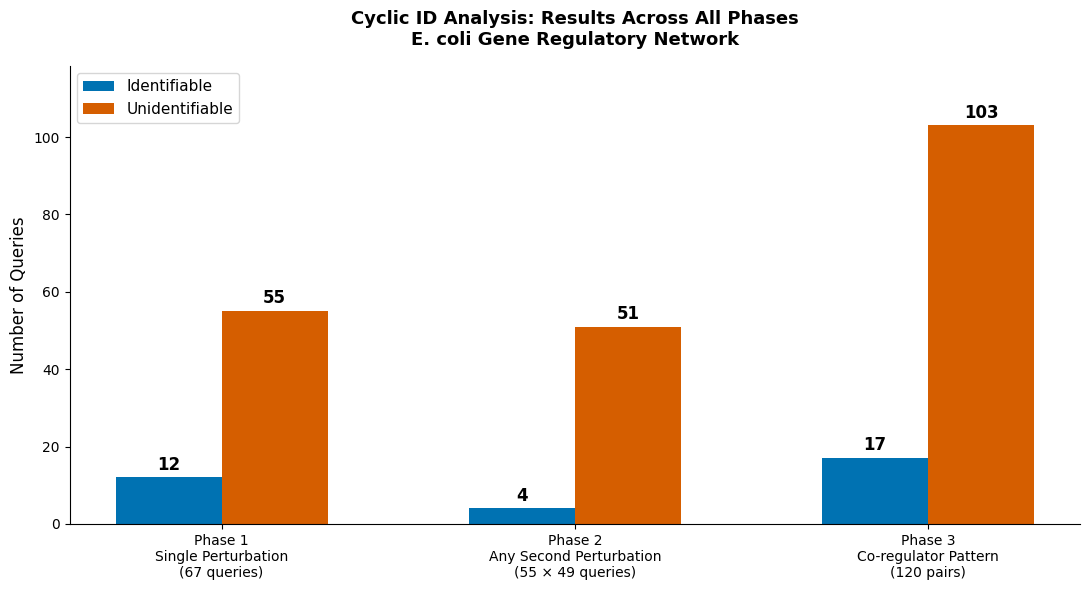

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(11, 6))

# color-blind friendly colors (Wong palette)
color_identifiable = "#0072B2"  # blue
color_unidentifiable = "#D55E00"  # orange-red

# data
phases = [
    "Phase 1\nSingle Perturbation\n(67 queries)",
    "Phase 2\nAny Second Perturbation\n(55 × 49 queries)",
    "Phase 3\nCo-regulator Pattern\n(120 pairs)",
]

identifiable_counts = [len(identifiable), len(resolved), len(p3_identifiable)]
unidentifiable_counts = [len(unidentifiable), len(still_unidentifiable), len(p3_unidentifiable)]

x = np.arange(len(phases))
width = 0.3

# plot bars
bars1 = ax.bar(
    x - width / 2, identifiable_counts, width, color=color_identifiable, label="Identifiable"
)
bars2 = ax.bar(
    x + width / 2, unidentifiable_counts, width, color=color_unidentifiable, label="Unidentifiable"
)

# add count labels on top of each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(phases, fontsize=10)
ax.set_ylabel("Number of Queries", fontsize=12)
ax.set_title(
    "Cyclic ID Analysis: Results Across All Phases\nE. coli Gene Regulatory Network",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.legend(fontsize=11)
ax.set_ylim(0, max(unidentifiable_counts) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("Dataset: Unidentifiable --> Identifiable Queries")
print("=" * 60)
print("Queries that became identifiable with a second perturbation\n")

# Phase 2 resolved queries (any second perturbation)
print("--- Phase 2: Any Second Perturbation ---")
phase2_resolved = [(tf1, tf2, outcome) for tf1, tf2, outcome, found, _ in phase2_results if found]
for tf1, tf2, outcome in phase2_resolved:
    print(f"  do({tf1}) -> {outcome}  |  becomes identifiable: do({tf2})")

print(f"\nTotal Phase 2 resolved: {len(phase2_resolved)}")

# Phase 3 resolved queries (co-regulator pattern)
print("\n--- Phase 3: Dual Regulatory Pattern ---")
for tf1, tf2, outcome in p3_identifiable:
    print(f"  do({tf1}) -> {outcome}  |  becomes identifiable: do({tf2})")

print(f"\nTotal Phase 3 resolved: {len(p3_identifiable)}")

# combined unique resolved queries
all_resolved = set((tf1, outcome) for tf1, tf2, outcome in phase2_resolved + p3_identifiable)
print(f"\nTotal unique (TF1, outcome) pairs resolved across both phases: {len(all_resolved)}")

Dataset: Unidentifiable --> Identifiable Queries
Queries that became identifiable with a second perturbation

--- Phase 2: Any Second Perturbation ---
  do(phoB) -> argP  |  becomes identifiable: do(rpoH)
  do(rpoS) -> yciT  |  becomes identifiable: do(lrp)
  do(crp) -> sgcR  |  becomes identifiable: do(lrp)
  do(lrp) -> yciT  |  becomes identifiable: do(rpoS)

Total Phase 2 resolved: 4

--- Phase 3: Co-regulator Pattern ---
  do(marA) -> lacZ  |  becomes identifiable: do(crp)
  do(marA) -> lacZ  |  becomes identifiable: do(lacI)
  do(marA) -> lacZ  |  becomes identifiable: do(hns)
  do(lacI) -> lacZ  |  becomes identifiable: do(marA)
  do(lacI) -> lacZ  |  becomes identifiable: do(crp)
  do(lacI) -> lacZ  |  becomes identifiable: do(hns)
  do(glaR) -> pdhR  |  becomes identifiable: do(fnr)
  do(glaR) -> pdhR  |  becomes identifiable: do(rpoS)
  do(glaR) -> pdhR  |  becomes identifiable: do(cra)
  do(glaR) -> pdhR  |  becomes identifiable: do(crp)
  do(marA) -> poxB  |  becomes identif

: 